In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import glob, os
import pandas as pd
import numpy as np
import re

ROOT = "../../results/full_methods_run"

def add_measures(df):
    df = df.copy()
    df["src_diff"]  = df["source_logp_A"] - df["source_logp_B"]
    df["base_diff"] = df["base_logp_A"]   - df["base_logp_B"]
    df["int_diff"]  = df["base_intervention_logp_A"] - df["base_intervention_logp_B"]
    df["odds"] = (df["base_logp_B"] - df["base_logp_A"]) \
               + (df["base_intervention_logp_A"] - df["base_intervention_logp_B"])
    return df

def load(pattern, seed=False):
    frames, skipped = [], []
    for path in sorted(glob.glob(pattern)):
        parts = path.split(os.sep)
        method = os.path.basename(path).replace(".csv", "")
        try:
            df = pd.read_csv(path)
        except pd.errors.EmptyDataError:
            skipped.append((path, "empty file")); continue
        if df.empty:
            skipped.append((path, "no rows")); continue

        # per-cell failures are written as -1.0 with a non-empty `error` column
        n_err = 0
        if "error" in df.columns:
            bad = df["error"].notna() & (df["error"].astype(str).str.strip() != "")
            n_err = int(bad.sum())
            df = df[~bad]
        if df.empty:
            skipped.append((path, "all cells failed")); continue

        df = add_measures(df)
        df["method"] = method
        df["model"]  = parts[-4] if not seed else parts[-5]
        df["stream"] = parts[-3] if not seed else parts[-4]
        df["cond"]   = parts[-2] if not seed else parts[-3]
        df["attractors"] = int(re.search(r"att(\d)", df["cond"].iloc[0]).group(1))
        df["seed"]   = int(parts[-2].split("_")[1]) if seed else -1
        df["n_failed_rows"] = n_err
        df["path"] = path
        frames.append(df)

    for p, why in skipped:
        print(f"  SKIP ({why}): {p}")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

main = load(f"{ROOT}/main/*/*/*/*.csv")
seed = load(f"{ROOT}/seed_sweep/*/*/*/seed_*/*.csv", seed=True)

print(f"\nmain: {len(main):,} rows from {main.path.nunique()} files")
print(main.groupby(["method", "model", "stream"]).size().unstack(fill_value=0))
print(f"\nseed: {len(seed):,} rows from {seed.path.nunique() if len(seed) else 0} files")


main: 748,720 rows from 48 files
stream                syntax  vision
method   model                      
das      Qwen3-VL-2B   74640   75936
         Qwen3-VL-4B   79968   87424
diffmean Qwen3-VL-2B   48276   49572
         Qwen3-VL-4B   46640   54176
probe    Qwen3-VL-2B   55476   56772
         Qwen3-VL-4B   56192   63648

seed: 888,000 rows from 60 files


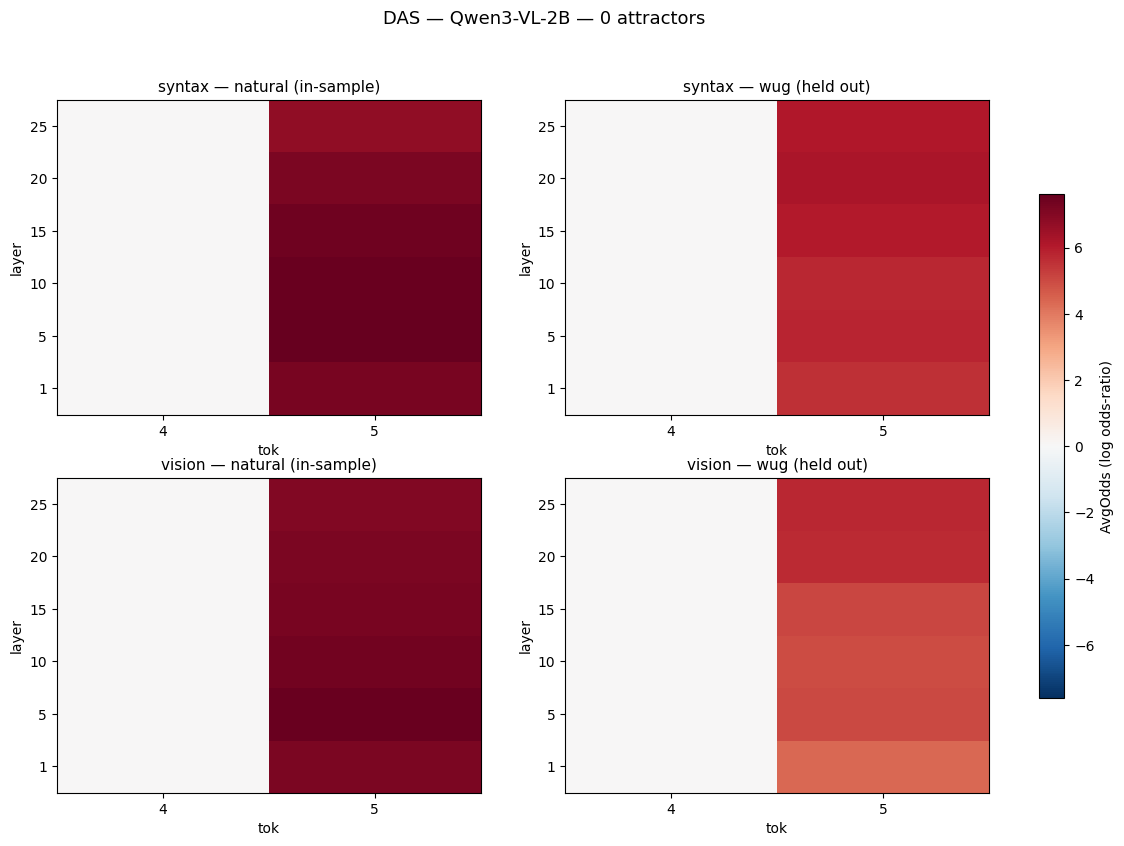

stream  split
syntax  test     9600
        train    9600
vision  test     9600
        train    9600
Name: rows, dtype: int64


In [3]:
METHOD = "das"          # "das" | "diffmean" | "probe"
MODEL  = "Qwen3-VL-2B"
COND   = "target_verb_att0_opp"

sub = main[(main.method == METHOD) & (main.model == MODEL) & (main.cond == COND)]
assert len(sub), "no rows — check METHOD/MODEL/COND"

def odds_grid(df):
    if df.empty: return None
    return df.groupby(["layer", "tok"])["odds"].mean().unstack("tok").sort_index()

PANELS = [(s, sp) for s in ("syntax", "vision") for sp in ("train", "test")]
grids = {(s, sp): odds_grid(sub[(sub.stream == s) & (sub.split == sp)])
         for s, sp in PANELS}
grids = {k: g for k, g in grids.items() if g is not None}
m = max(abs(g.values).max() for g in grids.values())

TITLE = {"train": "natural (in-sample)", "test": "wug (held out)"}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (s, sp) in zip(axes.ravel(), PANELS):
    g = grids.get((s, sp))
    if g is None:
        ax.axis("off"); continue
    im = ax.imshow(g.values, aspect="auto", cmap="RdBu_r",
                   origin="lower", vmin=-m, vmax=m)
    ax.set_xticks(range(len(g.columns))); ax.set_xticklabels(g.columns)
    ax.set_yticks(range(len(g.index)));   ax.set_yticklabels(g.index)
    ax.set_xlabel("tok"); ax.set_ylabel("layer")
    ax.set_title(f"{s} — {TITLE[sp]}", fontsize=11)

fig.colorbar(im, ax=axes.ravel().tolist(), label="AvgOdds (log odds-ratio)",
             fraction=0.025)
fig.suptitle(f"{METHOD.upper()} — {MODEL} — 0 attractors", fontsize=13)
plt.show()

print(sub.groupby(["stream", "split"]).size().rename("rows"))

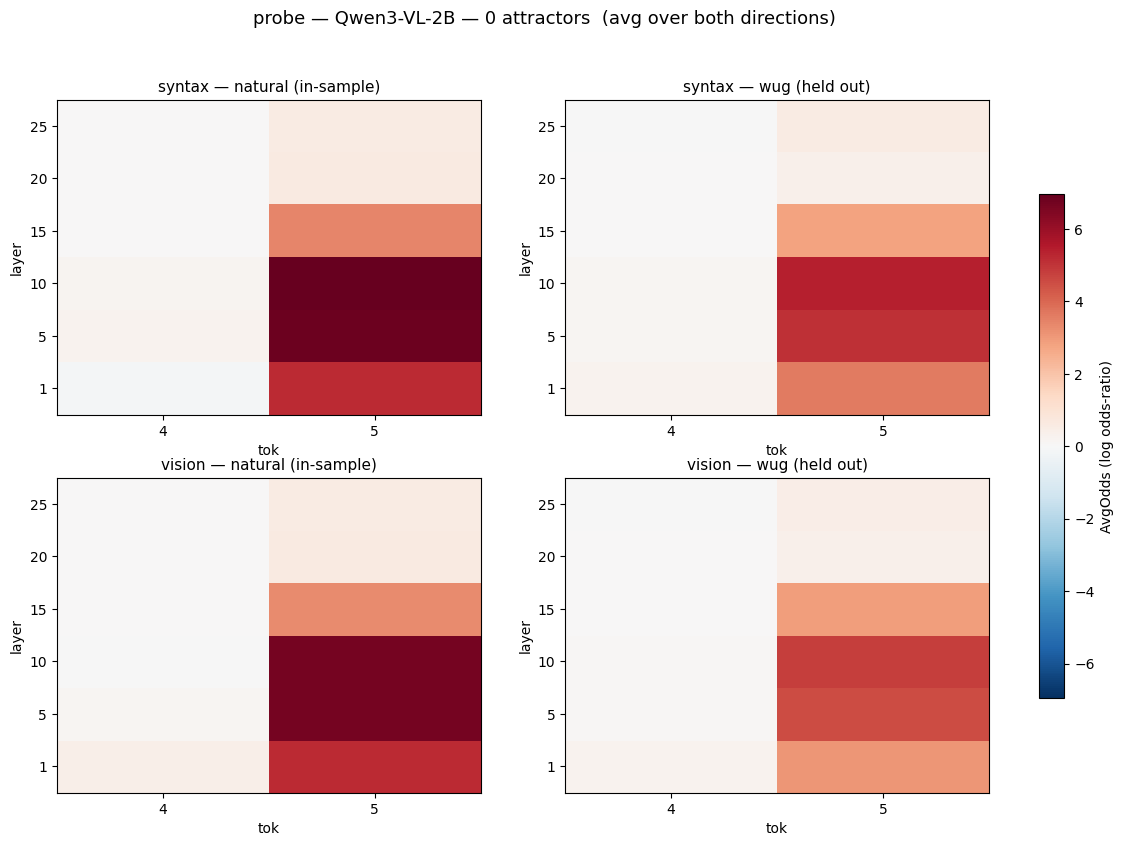

stream  split  inverse
syntax  test   0          4800
               1          4800
        train  0          4800
vision  test   0          4800
               1          4800
        train  0          4800
Name: rows, dtype: int64


In [4]:
METHOD = "probe"     # "das" | "diffmean" | "probe"
MODEL  = "Qwen3-VL-2B"
COND   = "target_verb_att0_opp"

sub = main[(main.method == METHOD) & (main.model == MODEL) & (main.cond == COND)]
assert len(sub), "no rows — check METHOD/MODEL/COND"

def odds_grid(df):
    if df.empty: return None
    return df.groupby(["layer", "tok"])["odds"].mean().unstack("tok").sort_index()

PANELS = [(s, sp) for s in ("syntax", "vision") for sp in ("train", "test")]
grids = {(s, sp): odds_grid(sub[(sub.stream == s) & (sub.split == sp)])
         for s, sp in PANELS}
grids = {k: g for k, g in grids.items() if g is not None}
m = max(abs(g.values).max() for g in grids.values())

TITLE = {"train": "natural (in-sample)", "test": "wug (held out)"}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (s, sp) in zip(axes.ravel(), PANELS):
    g = grids.get((s, sp))
    if g is None:
        ax.axis("off"); continue
    im = ax.imshow(g.values, aspect="auto", cmap="RdBu_r",
                   origin="lower", vmin=-m, vmax=m)
    ax.set_xticks(range(len(g.columns))); ax.set_xticklabels(g.columns)
    ax.set_yticks(range(len(g.index)));   ax.set_yticklabels(g.index)
    ax.set_xlabel("tok"); ax.set_ylabel("layer")
    ax.set_title(f"{s} — {TITLE[sp]}", fontsize=11)

fig.colorbar(im, ax=axes.ravel().tolist(), label="AvgOdds (log odds-ratio)",
             fraction=0.025)
fig.suptitle(f"{METHOD} — {MODEL} — 0 attractors  (avg over both directions)", fontsize=13)
plt.show()

print(sub.groupby(["stream", "split", "inverse"]).size().rename("rows"))

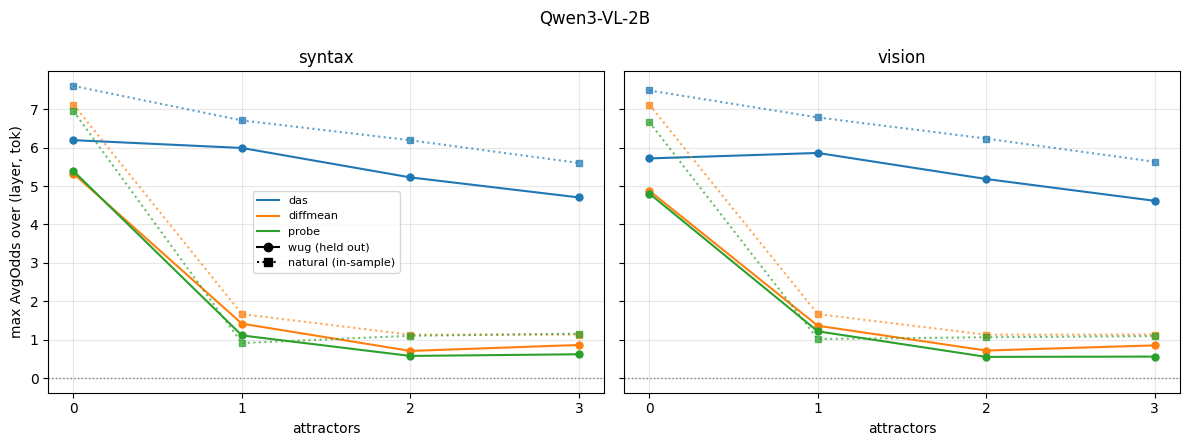

method                     das  diffmean  probe
stream attractors split                        
syntax 0          test   6.196     5.326  5.391
                  train  7.607     7.122  6.953
       1          test   5.993     1.418  1.111
                  train  6.710     1.666  0.913
       2          test   5.226     0.708  0.577
                  train  6.193     1.129  1.102
       3          test   4.705     0.863  0.621
                  train  5.602     1.135  1.156
vision 0          test   5.720     4.880  4.807
                  train  7.489     7.122  6.667
       1          test   5.862     1.364  1.218
                  train  6.787     1.666  1.019
       2          test   5.184     0.718  0.553
                  train  6.237     1.129  1.064
       3          test   4.616     0.852  0.560
                  train  5.633     1.135  1.094


In [5]:
MODEL = "Qwen3-VL-2B"
METHODS = ["das", "diffmean", "probe"]
COLORS = {"das": "tab:blue", "diffmean": "tab:orange", "probe": "tab:green"}

def max_odds(df):
    if df.empty: return np.nan, None
    g = df.groupby(["layer", "tok"])["odds"].mean()
    return g.max(), g.idxmax()

rows = []
for stream in ("syntax", "vision"):
    for mth in METHODS:
        for att in range(4):
            for split in ("train", "test"):
                sub = main[(main.method == mth) & (main.model == MODEL) &
                           (main.split == split) & (main.stream == stream) &
                           (main.attractors == att)]
                v, cell = max_odds(sub)
                rows.append(dict(stream=stream, method=mth, attractors=att,
                                 split=split, max_odds=v, argmax=cell, n=len(sub)))

mx = pd.DataFrame(rows)
STYLE = {"train": dict(ls=":", marker="s", ms=4, alpha=.7),
         "test":  dict(ls="-", marker="o", ms=5)}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, stream in zip(axes, ("syntax", "vision")):
    for mth in METHODS:
        for split in ("train", "test"):
            s = mx[(mx.stream == stream) & (mx.method == mth) &
                   (mx.split == split)].sort_values("attractors")
            ax.plot(s.attractors, s.max_odds, color=COLORS[mth], **STYLE[split])
    ax.axhline(0, color="grey", lw=1, ls=":")
    ax.set_xticks(range(4)); ax.set_xlabel("attractors")
    ax.set_title(stream); ax.grid(alpha=.3)

axes[0].set_ylabel("max AvgOdds over (layer, tok)")

from matplotlib.lines import Line2D
handles = [Line2D([], [], color=COLORS[m], label=m) for m in METHODS] + [
    Line2D([], [], color="k", ls="-",  marker="o", label="wug (held out)"),
    Line2D([], [], color="k", ls=":",  marker="s", label="natural (in-sample)")]
axes[0].legend(handles=handles, fontsize=8)
fig.suptitle(f"{MODEL}")
plt.tight_layout(); plt.show()

print(mx.pivot_table(index=["stream", "attractors", "split"],
                     columns="method", values="max_odds").round(3))

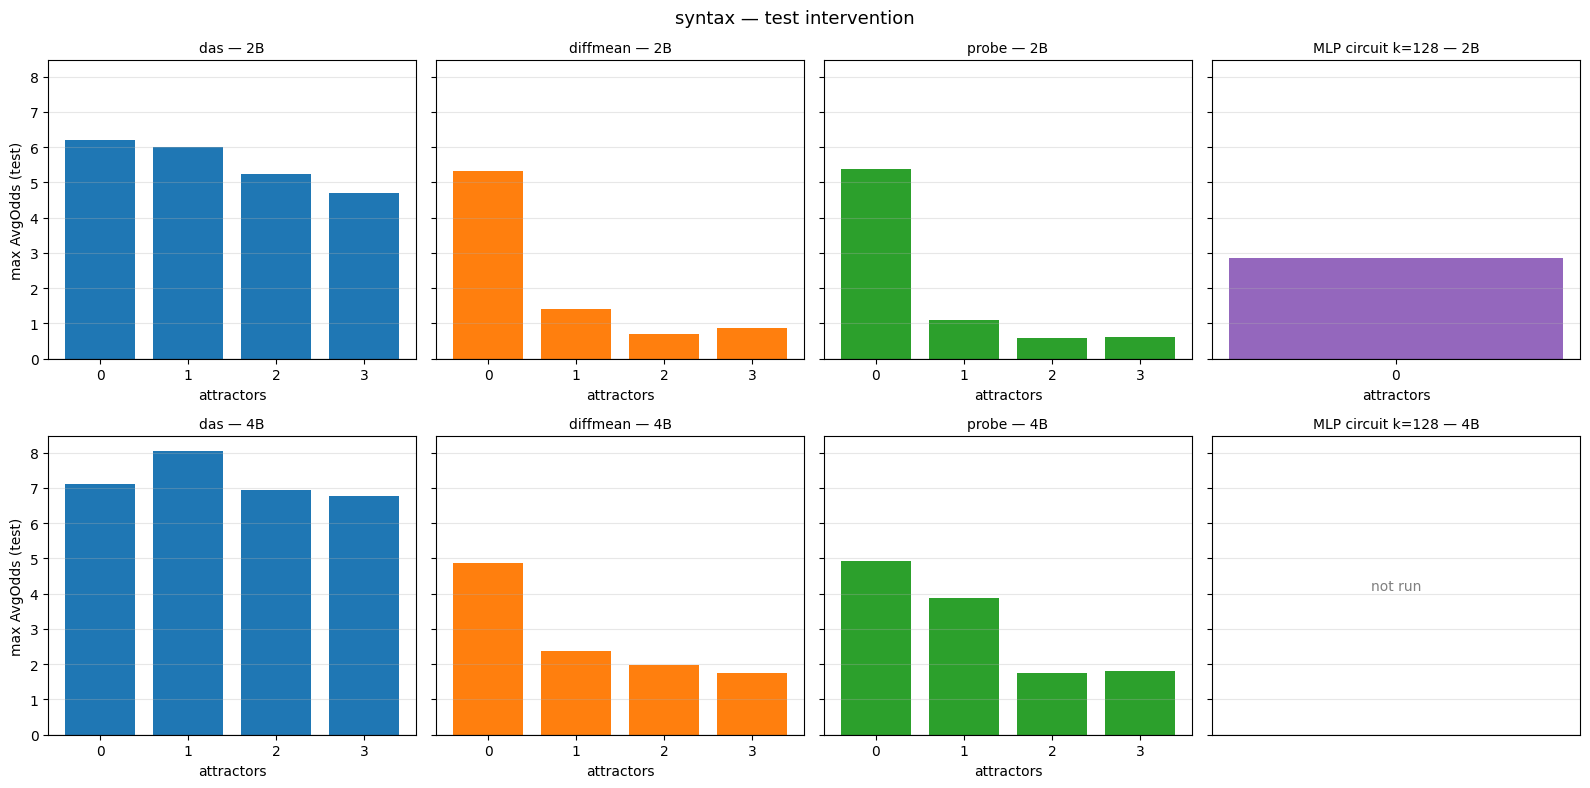

In [6]:
HPATH = "../../results/hook_comparison"
MLP_K = 128

def max_odds_scalar(df):
    if df.empty: return np.nan
    return df.groupby(["layer", "tok"])["odds"].mean().max()

def load_mlp(model):
    """mlp_act patch circuit. Returns mean odds on test, or nan."""
    p = f"{HPATH}/patch/mlp_act/patch_k{MLP_K}.csv"
    if model != "Qwen3-VL-2B" or not os.path.exists(p):
        return np.nan
    d = add_measures(pd.read_csv(p))
    d = d[d.split == "test"]
    return d.odds.mean() if len(d) else np.nan

MODELS  = ["Qwen3-VL-2B", "Qwen3-VL-4B"]
METHODS = ["das", "diffmean", "probe"]
COLORS  = {"das": "tab:blue", "diffmean": "tab:orange",
           "probe": "tab:green", "mlp": "tab:purple"}
STREAM  = "syntax"

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)

for r, model in enumerate(MODELS):
    for c, mth in enumerate(METHODS):
        ax = axes[r, c]
        vals = [max_odds_scalar(
                    main[(main.method == mth) & (main.model == model) &
                         (main.stream == STREAM) & (main.split == "test") &
                         (main.attractors == a)])
                for a in range(4)]
        ax.bar(range(4), vals, color=COLORS[mth])
        ax.set_xticks(range(4)); ax.set_xticklabels(range(4))
        ax.set_xlabel("attractors")
        ax.set_title(f"{mth} — {model.split('-')[-1]}", fontsize=10)
        ax.axhline(0, color="k", lw=.8)
        ax.grid(axis="y", alpha=.3)

    ax = axes[r, 3]
    v = load_mlp(model)
    if np.isnan(v):
        ax.text(.5, .5, "not run", ha="center", va="center",
                transform=ax.transAxes, color="grey")
        ax.set_xticks([])
    else:
        ax.bar([0], [v], color=COLORS["mlp"], width=.5)
        ax.set_xticks([0]); ax.set_xticklabels(["0"])
        ax.set_xlabel("attractors")
    ax.set_title(f"MLP circuit k={MLP_K} — {model.split('-')[-1]}", fontsize=10)
    ax.axhline(0, color="k", lw=.8); ax.grid(axis="y", alpha=.3)

    axes[r, 0].set_ylabel("max AvgOdds (test)")

fig.suptitle(f"{STREAM} — test intervention", fontsize=13)
plt.tight_layout(); plt.show()

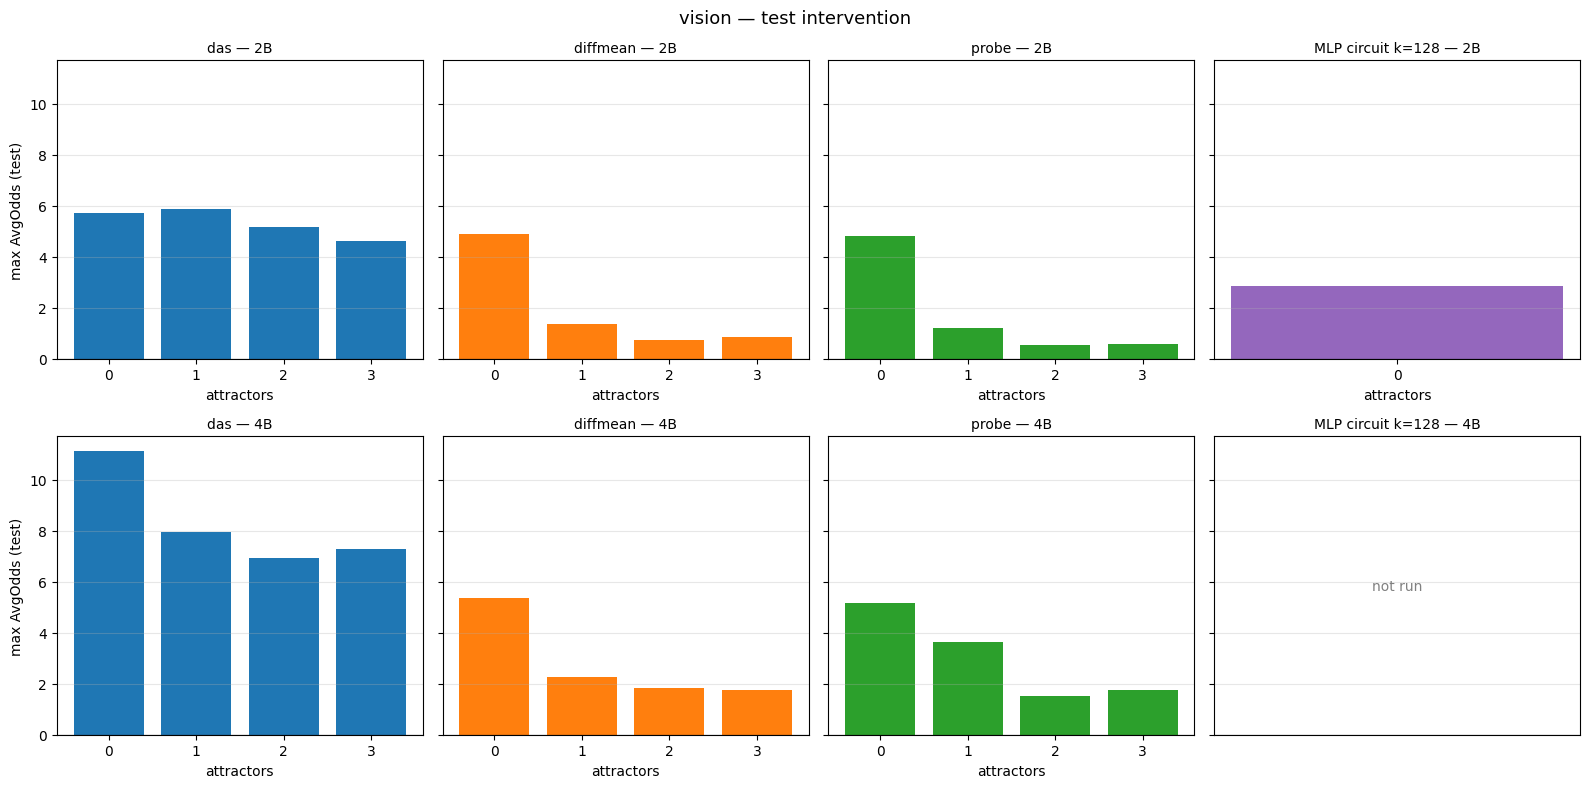

In [7]:
HPATH = "../../results/hook_comparison"
MLP_K = 128

def max_odds_scalar(df):
    if df.empty: return np.nan
    return df.groupby(["layer", "tok"])["odds"].mean().max()

def load_mlp(model):
    """mlp_act patch circuit. Returns mean odds on test, or nan."""
    p = f"{HPATH}/patch/mlp_act/patch_k{MLP_K}.csv"
    if model != "Qwen3-VL-2B" or not os.path.exists(p):
        return np.nan
    d = add_measures(pd.read_csv(p))
    d = d[d.split == "test"]
    return d.odds.mean() if len(d) else np.nan

MODELS  = ["Qwen3-VL-2B", "Qwen3-VL-4B"]
METHODS = ["das", "diffmean", "probe"]
COLORS  = {"das": "tab:blue", "diffmean": "tab:orange",
           "probe": "tab:green", "mlp": "tab:purple"}
STREAM  = "vision"

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)

for r, model in enumerate(MODELS):
    for c, mth in enumerate(METHODS):
        ax = axes[r, c]
        vals = [max_odds_scalar(
                    main[(main.method == mth) & (main.model == model) &
                         (main.stream == STREAM) & (main.split == "test") &
                         (main.attractors == a)])
                for a in range(4)]
        ax.bar(range(4), vals, color=COLORS[mth])
        ax.set_xticks(range(4)); ax.set_xticklabels(range(4))
        ax.set_xlabel("attractors")
        ax.set_title(f"{mth} — {model.split('-')[-1]}", fontsize=10)
        ax.axhline(0, color="k", lw=.8)
        ax.grid(axis="y", alpha=.3)

    ax = axes[r, 3]
    v = load_mlp(model)
    if np.isnan(v):
        ax.text(.5, .5, "not run", ha="center", va="center",
                transform=ax.transAxes, color="grey")
        ax.set_xticks([])
    else:
        ax.bar([0], [v], color=COLORS["mlp"], width=.5)
        ax.set_xticks([0]); ax.set_xticklabels(["0"])
        ax.set_xlabel("attractors")
    ax.set_title(f"MLP circuit k={MLP_K} — {model.split('-')[-1]}", fontsize=10)
    ax.axhline(0, color="k", lw=.8); ax.grid(axis="y", alpha=.3)

    axes[r, 0].set_ylabel("max AvgOdds (test)")

fig.suptitle(f"{STREAM} — test intervention", fontsize=13)
plt.tight_layout(); plt.show()

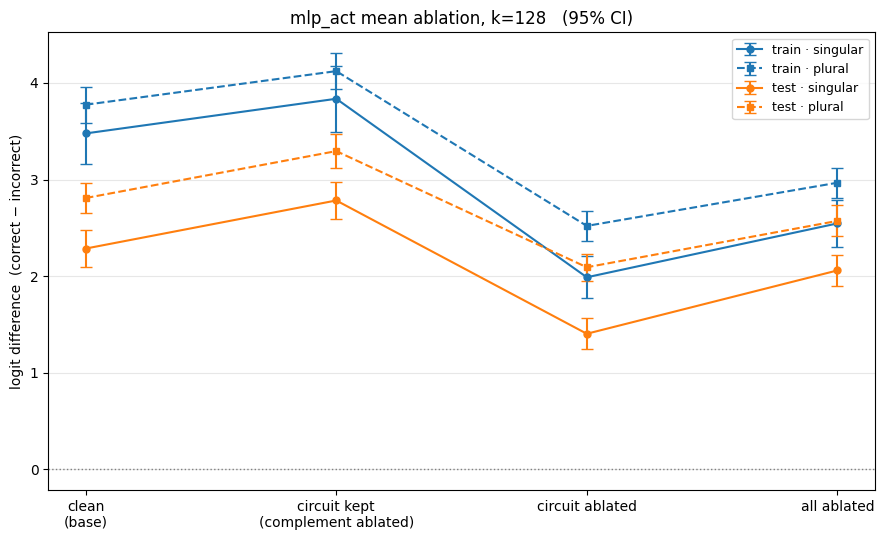

run             clean  complement_ablation  circuit_ablation  all_ablation  \
split number                                                                 
test  plural    2.809                3.295             2.092         2.572   
      singular  2.285                2.783             1.403         2.059   
train plural    3.775                4.123             2.520         2.967   
      singular  3.478                3.836             1.988         2.546   

run             faithfulness  completeness  
split number                                
test  plural           3.051        -2.026  
      singular         3.195        -2.889  
train plural           1.430        -0.553  
      singular         1.385        -0.598  


In [8]:
APATH = "../../results/hook_comparison/ablation/mlp_act"
abl = pd.read_csv(f"{APATH}/ablation_k128.csv")

RUNS = ["clean", "complement_ablation", "circuit_ablation", "all_ablation"]
LABELS = ["clean\n(base)", "circuit kept\n(complement ablated)",
          "circuit ablated", "all ablated"]

for p in RUNS:
    abl[f"m_{p}"] = abl[f"{p}_logp_A"] - abl[f"{p}_logp_B"]
abl["number"] = abl["inverse"].map({0: "singular", 1: "plural"})

def ci95(s):
    return 1.96 * s.std(ddof=1) / np.sqrt(len(s)) if len(s) > 1 else np.nan

stats = (abl.melt(id_vars=["split", "number"],
                  value_vars=[f"m_{p}" for p in RUNS],
                  var_name="run", value_name="m")
            .assign(run=lambda d: d["run"].str[2:])
            .groupby(["split", "number", "run"])["m"]
            .agg(mean="mean", ci=ci95).reset_index())

x = np.arange(len(RUNS))
STYLE = {("train", "singular"): ("tab:blue",  "-",  "o"),
         ("train", "plural"):   ("tab:blue",  "--", "s"),
         ("test",  "singular"): ("tab:orange", "-",  "o"),
         ("test",  "plural"):   ("tab:orange", "--", "s")}

fig, ax = plt.subplots(figsize=(9, 5.5))
for (split, number), (c, ls, mk) in STYLE.items():
    s = stats[(stats.split == split) & (stats.number == number)]
    if s.empty: continue
    s = s.set_index("run").loc[RUNS]
    ax.errorbar(x, s["mean"], yerr=s["ci"], color=c, ls=ls, marker=mk,
                ms=5, capsize=4, lw=1.5, label=f"{split} · {number}")

ax.axhline(0, color="grey", lw=1, ls=":")
ax.set_xticks(x); ax.set_xticklabels(LABELS)
ax.set_ylabel("logit difference  (correct − incorrect)")
ax.set_title(f"mlp_act mean ablation, k={abl.n_nodes.iloc[0]}   (95% CI)")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

g = stats.pivot_table(index=["split","number"], columns="run", values="mean")[RUNS]
den = g["clean"] - g["all_ablation"]
g["faithfulness"] = (g["complement_ablation"] - g["all_ablation"]) / den
g["completeness"] = (g["circuit_ablation"]    - g["all_ablation"]) / den
print(g.round(3))

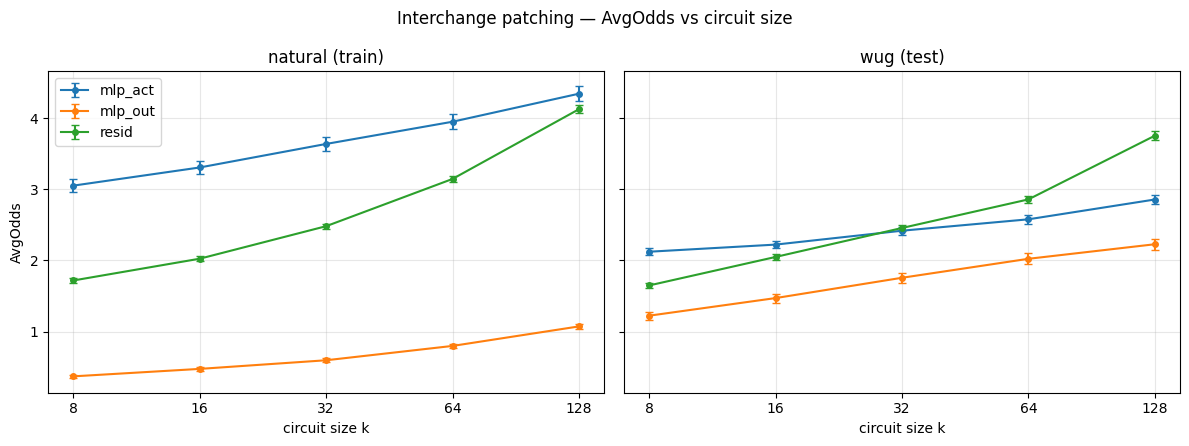

hook  mlp_act  mlp_out  resid
k                            
8       2.123    1.224  1.649
16      2.223    1.472  2.049
32      2.418    1.757  2.456
64      2.578    2.023  2.858
128     2.856    2.228  3.752


In [9]:
HPATH = "../../results/hook_comparison/patch"
HOOKS = ["mlp_act", "mlp_out", "resid"]
KS    = [8, 16, 32, 64, 128]
COLORS = {"mlp_act": "tab:blue", "mlp_out": "tab:orange", "resid": "tab:green"}

rows, missing = [], []
for h in HOOKS:
    for k in KS:
        p = f"{HPATH}/{h}/patch_k{k}.csv"
        if not os.path.exists(p):
            missing.append(p)
            continue
        d = add_measures(pd.read_csv(p))
        for split, g in d.groupby("split"):
            rows.append(dict(hook=h, k=k, split=split, n=len(g),
                             odds=g["odds"].mean(),
                             odds_sem=g["odds"].sem()))

for p in missing:
    print("MISSING:", p)

pw = pd.DataFrame(rows)
assert len(pw), "no files loaded"

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, split in zip(axes, ["train", "test"]):
    for h in HOOKS:
        s = pw[(pw["hook"] == h) & (pw["split"] == split)].sort_values("k")
        if s.empty:
            continue
        ax.errorbar(s["k"], s["odds"], yerr=s["odds_sem"],
                    marker="o", ms=4, capsize=3, color=COLORS[h], label=h)
    ax.set_xscale("log", base=2)
    ax.set_xticks(KS); ax.set_xticklabels(KS)
    ax.set_xlabel("circuit size k")
    ax.grid(alpha=.3)
    ax.set_title("natural (train)" if split == "train" else "wug (test)")

axes[0].set_ylabel("AvgOdds")
axes[0].legend()
fig.suptitle("Interchange patching — AvgOdds vs circuit size")
plt.tight_layout(); plt.show()

print(pw[pw["split"] == "test"]
      .pivot_table(index="k", columns="hook", values="odds").round(3))

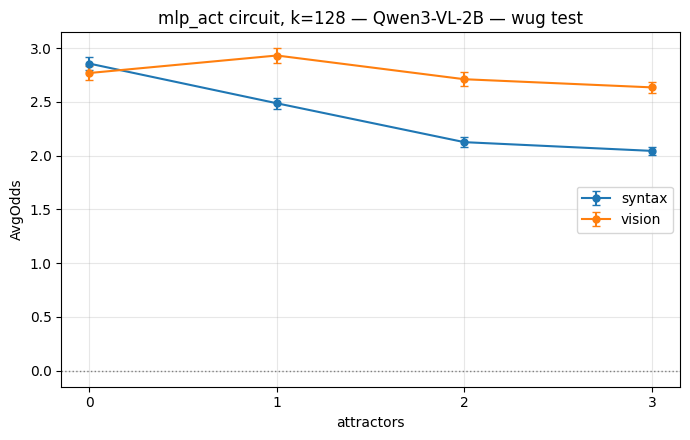

stream      syntax  vision
attractors                
0            2.856   2.769
1            2.487   2.932
2            2.125   2.711
3            2.044   2.635
stream      syntax  vision
attractors                
0            400.0   400.0
1            400.0   400.0
2            400.0   400.0
3            400.0   400.0


In [10]:
CPATH = "../../results/circuits_k128"
MODEL = "Qwen3-VL-2B"
K = 128
COLORS = {"syntax": "tab:blue", "vision": "tab:orange"}

rows, missing = [], []
for stream in ("syntax", "vision"):
    for att in range(4):
        cond = f"target_verb_att{att}_opp"
        p = f"{CPATH}/patch/{MODEL}/{stream}/{cond}/patch_k{K}.csv"
        if not os.path.exists(p):
            missing.append(p)
            continue
        d = add_measures(pd.read_csv(p))
        g = d[d["split"] == "test"]
        rows.append(dict(stream=stream, attractors=att, n=len(g),
                         odds=g["odds"].mean(), odds_sem=g["odds"].sem()))

for p in missing:
    print("MISSING:", p)

ck = pd.DataFrame(rows)
assert len(ck), "no files loaded"

fig, ax = plt.subplots(figsize=(7, 4.5))
for stream in ("syntax", "vision"):
    s = ck[ck["stream"] == stream].sort_values("attractors")
    if s.empty:
        continue
    ax.errorbar(s["attractors"], s["odds"], yerr=s["odds_sem"],
                marker="o", ms=5, capsize=3, color=COLORS[stream], label=stream)

ax.axhline(0, color="grey", lw=1, ls=":")
ax.set_xticks(range(4))
ax.set_xlabel("attractors")
ax.set_ylabel("AvgOdds")
ax.set_title(f"mlp_act circuit, k={K} — {MODEL} — wug test")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(ck.pivot_table(index="attractors", columns="stream", values="odds").round(3))
print(ck.pivot_table(index="attractors", columns="stream", values="n"))

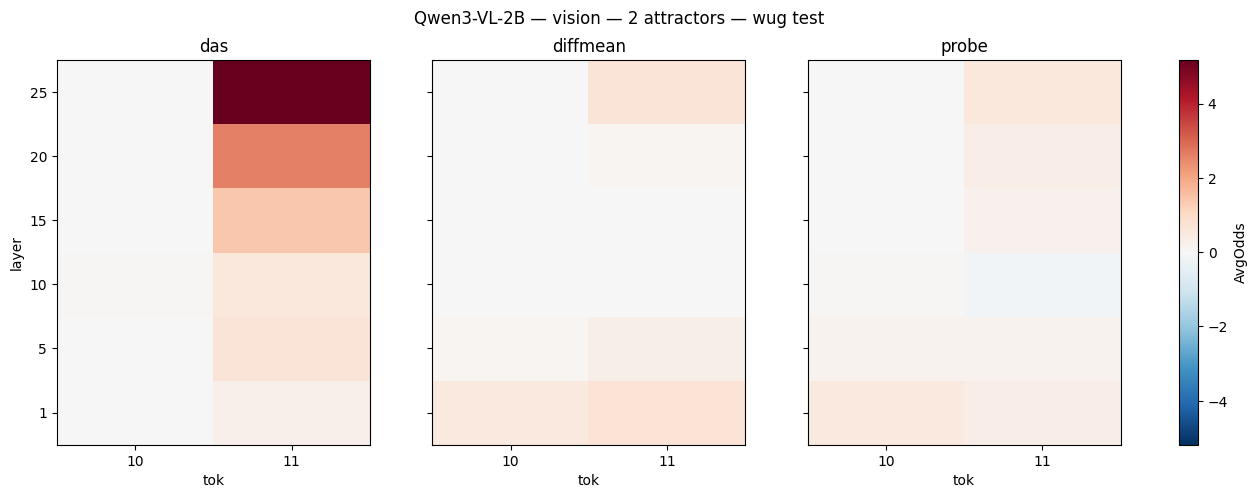


das  (max 5.184 at (25, 11))
tok       10     11
layer              
1      0.002  0.281
5      0.014  0.674
10     0.041  0.560
15     0.025  1.410
20     0.022  2.613
25    -0.004  5.184

diffmean  (max 0.718 at (1, 11))
tok       10     11
layer              
1      0.506  0.718
5      0.093  0.323
10     0.022  0.012
15     0.036 -0.018
20     0.030  0.099
25    -0.001  0.684

probe  (max 0.553 at (25, 11))
tok       10     11
layer              
1      0.504  0.364
5      0.188  0.174
10     0.064 -0.134
15     0.031  0.220
20     0.017  0.355
25    -0.000  0.553


In [11]:
MODEL, STREAM, ATT, SPLIT = "Qwen3-VL-2B", "vision", 2, "test"
METHODS = ["das", "diffmean", "probe"]

def odds_grid(df):
    if df.empty: return None
    return df.groupby(["layer", "tok"])["odds"].mean().unstack("tok").sort_index()

sel = main[(main["model"] == MODEL) & (main["stream"] == STREAM) &
           (main["attractors"] == ATT) & (main["split"] == SPLIT)]
assert len(sel), "no rows — is att3 finished?"

grids = {m: odds_grid(sel[sel["method"] == m]) for m in METHODS}
grids = {k: g for k, g in grids.items() if g is not None}
m = max(abs(g.values).max() for g in grids.values())   # shared scale

fig, axes = plt.subplots(1, len(grids), figsize=(5 * len(grids), 5), sharey=True)
axes = np.atleast_1d(axes)
for ax, (mth, g) in zip(axes, grids.items()):
    im = ax.imshow(g.values, aspect="auto", cmap="RdBu_r",
                   origin="lower", vmin=-m, vmax=m)
    ax.set_xticks(range(len(g.columns))); ax.set_xticklabels(g.columns)
    ax.set_yticks(range(len(g.index)));   ax.set_yticklabels(g.index)
    ax.set_xlabel("tok"); ax.set_title(mth)
axes[0].set_ylabel("layer")
fig.colorbar(im, ax=axes.tolist(), label="AvgOdds", fraction=0.035)
fig.suptitle(f"{MODEL} — {STREAM} — {ATT} attractors — wug test")
plt.show()

for mth, g in grids.items():
    print(f"\n{mth}  (max {g.values.max():.3f} at {g.stack().idxmax()})")
    print(g.round(3))

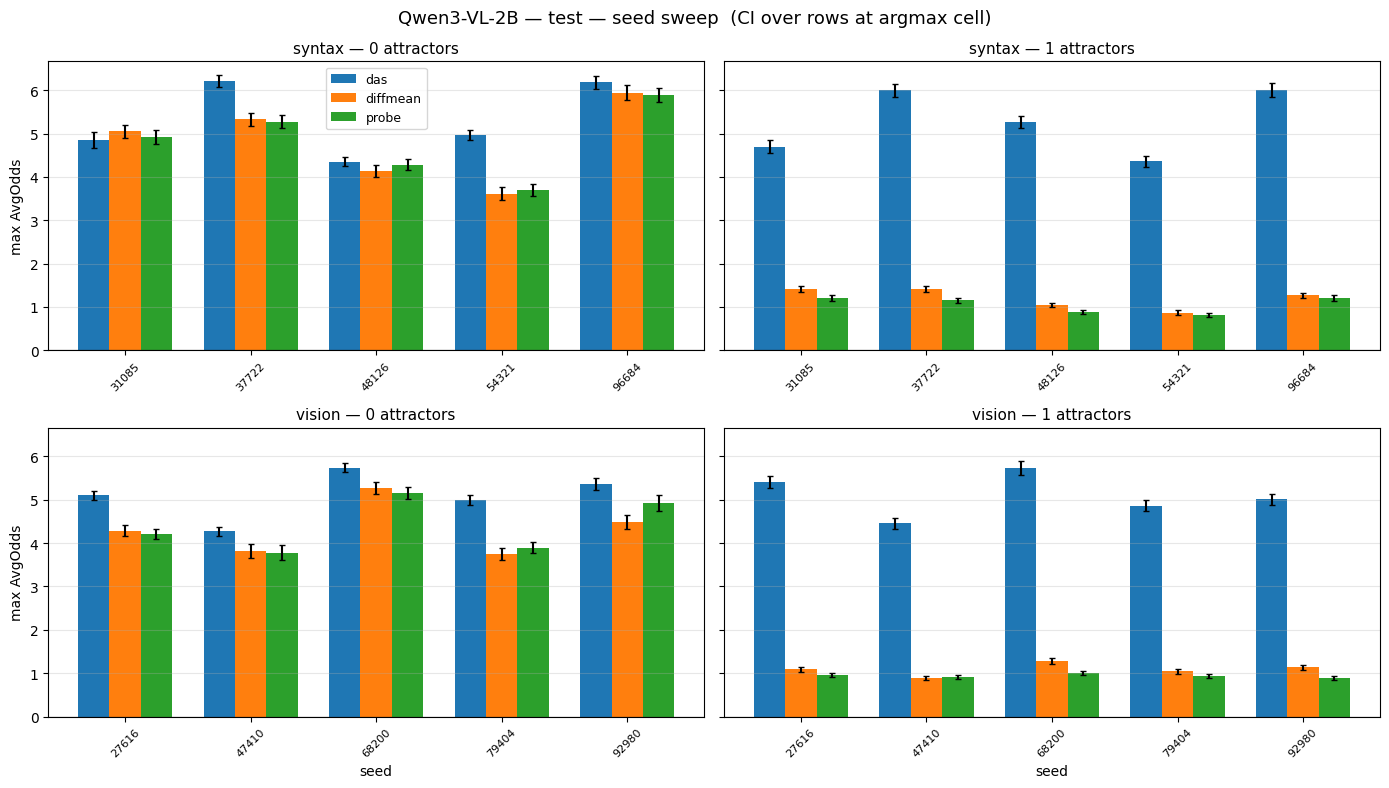

                             mean    std    min    max
stream attractors method                              
syntax 0          das       5.312  0.839  4.351  6.210
                  diffmean  4.813  0.935  3.608  5.943
                  probe     4.809  0.852  3.695  5.888
       1          das       5.265  0.748  4.356  6.008
                  diffmean  1.204  0.239  0.872  1.418
                  probe     1.056  0.188  0.819  1.215
vision 0          das       5.093  0.544  4.268  5.743
                  diffmean  4.320  0.612  3.747  5.264
                  probe     4.391  0.619  3.776  5.157
       1          das       5.093  0.496  4.453  5.736
                  diffmean  1.090  0.144  0.890  1.287
                  probe     0.940  0.042  0.897  1.004


In [12]:
CPATH = "../../results/full_methods_run/seed_sweep"
MODEL, SPLIT = "Qwen3-VL-2B", "test"
METHODS = ["das", "diffmean", "probe"]
COLORS  = {"das": "tab:blue", "diffmean": "tab:orange", "probe": "tab:green"}
STREAMS = ["syntax", "vision"]
ATTS    = [0, 1]

def max_cell_with_ci(df):
    """Max over (layer,tok) of mean odds; 95% CI is over rows at that cell."""
    if df.empty: return np.nan, np.nan
    cell_mean = df.groupby(["layer", "tok"])["odds"].mean()
    cell = cell_mean.idxmax()
    at = df[(df["layer"] == cell[0]) & (df["tok"] == cell[1])]["odds"]
    ci = 1.96 * at.std(ddof=1) / np.sqrt(len(at)) if len(at) > 1 else np.nan
    return cell_mean.max(), ci

rows, missing = [], []
for stream in STREAMS:
    for att in ATTS:
        cond = f"target_verb_att{att}_opp"
        for sd in sorted(glob.glob(f"{CPATH}/{MODEL}/{stream}/{cond}/seed_*")):
            seed = int(os.path.basename(sd).split("_")[1])
            for mth in METHODS:
                p = f"{sd}/{mth}.csv"
                if not os.path.exists(p):
                    missing.append(p); continue
                d = add_measures(pd.read_csv(p))
                d = d[d["split"] == SPLIT]
                v, ci = max_cell_with_ci(d)
                rows.append(dict(stream=stream, attractors=att, seed=seed,
                                 method=mth, odds=v, ci=ci))

for p in missing: print("MISSING:", p)
sw = pd.DataFrame(rows)
assert len(sw), "no files loaded"

fig, axes = plt.subplots(len(STREAMS), len(ATTS), figsize=(14, 8), sharey=True)
w = 0.25
for r, stream in enumerate(STREAMS):
    for c, att in enumerate(ATTS):
        ax = axes[r, c]
        cell = sw[(sw["stream"] == stream) & (sw["attractors"] == att)]
        seeds = sorted(cell["seed"].unique())
        x = np.arange(len(seeds))
        for i, mth in enumerate(METHODS):
            vals = [cell[(cell["seed"] == s) & (cell["method"] == mth)]["odds"].squeeze()
                    if len(cell[(cell["seed"] == s) & (cell["method"] == mth)]) else np.nan
                    for s in seeds]
            errs = [cell[(cell["seed"] == s) & (cell["method"] == mth)]["ci"].squeeze()
                    if len(cell[(cell["seed"] == s) & (cell["method"] == mth)]) else np.nan
                    for s in seeds]
            ax.bar(x + (i - 1) * w, vals, w, yerr=errs, capsize=2,
                   color=COLORS[mth], label=mth if (r == 0 and c == 0) else None)
        ax.set_xticks(x); ax.set_xticklabels(seeds, rotation=45, fontsize=8)
        ax.axhline(0, color="k", lw=.8); ax.grid(axis="y", alpha=.3)
        ax.set_title(f"{stream} — {att} attractors", fontsize=11)
        if c == 0: ax.set_ylabel("max AvgOdds")
        if r == len(STREAMS) - 1: ax.set_xlabel("seed")

axes[0, 0].legend(fontsize=9)
fig.suptitle(f"{MODEL} — {SPLIT} — seed sweep  (CI over rows at argmax cell)", fontsize=13)
plt.tight_layout(); plt.show()

print(sw.groupby(["stream", "attractors", "method"])["odds"]
        .agg(["mean", "std", "min", "max"]).round(3))